# Tahap 1 — Membangun Case Base
## CBR Sistem Analisis Putusan Narkotika

**Tujuan:** Mengumpulkan (*scraping*) dan menyiapkan (*cleaning*) corpus putusan yang bersih.

**Langkah:**
1. Generate / unduh dokumen putusan (≥30 dokumen)
2. Konversi & ekstraksi teks
3. Pembersihan teks (hapus header/footer, normalisasi, tokenisasi)
4. Validasi kelengkapan teks (≥80%)
5. Simpan ke `/data/raw/` dan catat di `logs/cleaning.log`

## 1.0 Setup & Import

In [1]:
import os, re, sys, logging
from datetime import datetime

# Pastikan working directory di root project
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(ROOT)
print(f'Working directory: {ROOT}')

Working directory: e:\ragil\semester 6\Penalaran Komputer\cbr_narkotika\cbr_narkotika


## 1.1 Generate / Unduh Dokumen Putusan

> **Catatan implementasi nyata:** Ganti sel berikut dengan scraper dari Direktori MA RI:
> ```
> https://putusan3.mahkamahagung.go.id/
> Filter: Pidana Khusus → Narkotika & Psikotropika
> ```
> Gunakan `requests` + `BeautifulSoup` untuk HTML, atau `pdfminer.six` untuk PDF.

In [2]:
# Generate 35 dokumen putusan sintetis (representasi struktur putusan MA RI)
%run generate_data.py

raw_files = sorted(os.listdir('data/raw'))
print(f'\nTotal dokumen: {len(raw_files)}')
print('Contoh file:', raw_files[:5])

  [+] case_001.txt  |  101/Pid.Sus/2023/PN.Bdg  |  Ahmad Fauzi
  [+] case_002.txt  |  102/Pid.Sus/2022/PN.Mdn  |  Budi Santoso
  [+] case_003.txt  |  103/Pid.Sus/2020/PN.Mdn  |  Cipto Haryono
  [+] case_004.txt  |  104/Pid.Sus/2022/PN.Mks  |  Dedi Kurniawan
  [+] case_005.txt  |  105/Pid.Sus/2022/PN.Sby  |  Eko Prasetyo
  [+] case_006.txt  |  106/Pid.Sus/2023/PN.Mdn  |  Fahri Maulana
  [+] case_007.txt  |  107/Pid.Sus/2023/PN.Mdn  |  Gunawan Hidayat
  [+] case_008.txt  |  108/Pid.Sus/2022/PN.Mks  |  Hendra Wijaya
  [+] case_009.txt  |  109/Pid.Sus/2024/PN.Jkt.Sel  |  Irwan Saputra
  [+] case_010.txt  |  110/Pid.Sus/2021/PN.Bdg  |  Joko Susilo
  [+] case_011.txt  |  111/Pid.Sus/2022/PN.Jkt.Sel  |  Kurnia Ramadhan
  [+] case_012.txt  |  112/Pid.Sus/2022/PN.Sby  |  Lukman Hakim
  [+] case_013.txt  |  113/Pid.Sus/2022/PN.Bdg  |  Muhamad Rizky
  [+] case_014.txt  |  114/Pid.Sus/2020/PN.Mks  |  Nanang Setiawan
  [+] case_015.txt  |  115/Pid.Sus/2020/PN.Bdg  |  Oki Firmansyah
  [+] case_016.t

## 1.2 Inspeksi Dokumen Mentah

In [3]:
# Tampilkan contoh dokumen mentah
with open('data/raw/case_001.txt', 'r', encoding='utf-8') as f:
    raw_sample = f.read()

print('=== DOKUMEN MENTAH (500 karakter pertama) ===')
print(raw_sample[:500])
print('...')
print(f'\nPanjang dokumen: {len(raw_sample)} karakter')

=== DOKUMEN MENTAH (500 karakter pertama) ===
PUTUSAN
Nomor 101/Pid.Sus/2023/PN.Bdg

DEMI KEADILAN BERDASARKAN KETUHANAN YANG MAHA ESA

PENGADILAN NEGERI JAKARTA SELATAN

yang memeriksa dan mengadili perkara pidana khusus Narkotika dan Psikotropika pada 
tingkat pertama, telah menjatuhkan putusan sebagai berikut dalam perkara Terdakwa:

Nama Lengkap   : Ahmad Fauzi
Tempat Lahir   : Jakarta
Umur/Tanggal Lahir : 50 Tahun
Jenis Kelamin  : Laki-laki
Kebangsaan     : Indonesia
Agama          : Katolik
Pekerjaan      : Swasta
Alamat         : Jl.
...

Panjang dokumen: 3843 karakter


## 1.3 Fungsi Preprocessing & Cleaning

In [4]:
REQUIRED_SECTIONS = ['DAKWAAN', 'FAKTA', 'MENGADILI']

def remove_watermark(text):
    """Hapus watermark umum pada dokumen PDF hasil scan."""
    return re.sub(r'(?im)^(SALINAN|TURUNAN|COPY|MAHKAMAH AGUNG RI)\s*$', '', text)

def remove_page_numbers(text):
    """Hapus nomor halaman: '- 5 -', 'Halaman 5 dari 20', dll."""
    text = re.sub(r'(?m)^\s*[-–]\s*\d+\s*[-–]\s*$', '', text)
    text = re.sub(r'(?m)^\s*Hal(?:aman)?\s+\d+\s+dari\s+\d+\s*$', '', text, flags=re.IGNORECASE)
    return text

def normalize_whitespace(text):
    """Normalisasi spasi dan baris kosong."""
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def tokenize(text):
    """Tokenisasi sederhana: split per kata alfanumerik."""
    return re.findall(r'\b[a-z0-9]+\b', text.lower())

def clean_document(raw_text):
    text = remove_watermark(raw_text)
    text = remove_page_numbers(text)
    text = normalize_whitespace(text)
    return text

def validate_document(cleaned_text, raw_text):
    pct     = len(cleaned_text) / max(len(raw_text), 1) * 100
    missing = [s for s in REQUIRED_SECTIONS if s not in cleaned_text.upper()]
    return {'valid': pct >= 80 and not missing, 'pct': round(pct, 1), 'missing': missing}

print('✓ Fungsi preprocessing siap')

✓ Fungsi preprocessing siap


## 1.4 Jalankan Pipeline Cleaning

In [5]:
import pandas as pd

os.makedirs('logs', exist_ok=True)
log_lines = []
summary = []

files = sorted(f for f in os.listdir('data/raw') if f.endswith('.txt'))

for fname in files:
    fpath = os.path.join('data/raw', fname)
    with open(fpath, 'r', encoding='utf-8') as f:
        raw = f.read()
    
    cleaned  = clean_document(raw)
    tokens   = tokenize(cleaned)
    result   = validate_document(cleaned, raw)
    status   = 'OK' if result['valid'] else 'WARN'
    
    log_line = (f"[{status}] {fname:20s} | pct={result['pct']:5.1f}%"
                f" | tokens={len(tokens):5d}"
                + (f" | missing={result['missing']}" if result['missing'] else ''))
    log_lines.append(log_line)
    
    # Overwrite dengan teks bersih
    with open(fpath, 'w', encoding='utf-8') as f:
        f.write(cleaned)
    
    summary.append({
        'file': fname, 'status': status,
        'pct_retained': result['pct'], 'token_count': len(tokens),
        'valid': result['valid']
    })

# Simpan log
with open('logs/cleaning.log', 'w', encoding='utf-8') as f:
    f.write(f'[Cleaning Log] {datetime.now()}\n')
    f.write('\n'.join(log_lines))

df_log = pd.DataFrame(summary)
passed = df_log['valid'].sum()
print(f'✓ {passed}/{len(df_log)} dokumen lolos validasi')
print(f'✓ Cleaning log disimpan → logs/cleaning.log\n')
df_log

✓ 35/35 dokumen lolos validasi
✓ Cleaning log disimpan → logs/cleaning.log



,file,status,pct_retained,token_count,valid
0,case_001.txt,OK,98.5,521,True
1,case_002.txt,OK,98.4,517,True
2,case_003.txt,OK,98.4,501,True
3,case_004.txt,OK,98.5,518,True
4,case_005.txt,OK,98.4,504,True
5,case_006.txt,OK,98.4,508,True
6,case_007.txt,OK,98.5,518,True
7,case_008.txt,OK,98.4,510,True
8,case_009.txt,OK,98.5,525,True
9,case_010.txt,OK,98.5,518,True


## 1.5 Visualisasi Statistik Dokumen

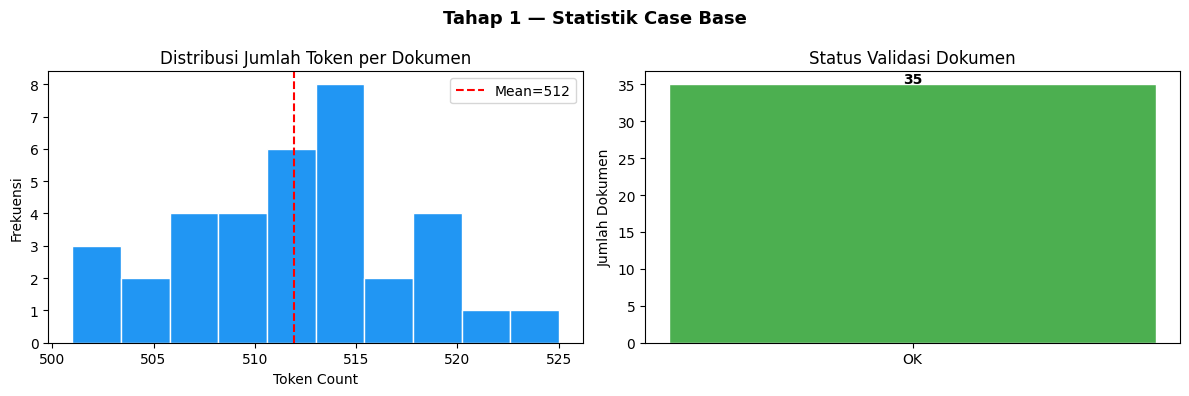

Grafik tersimpan → data/eval/tahap1_stats.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Tahap 1 — Statistik Case Base', fontsize=13, fontweight='bold')

# Distribusi token count
axes[0].hist(df_log['token_count'], bins=10, color='#2196F3', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Token per Dokumen')
axes[0].set_xlabel('Token Count')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_log['token_count'].mean(), color='red',
                linestyle='--', label=f"Mean={df_log['token_count'].mean():.0f}")
axes[0].legend()

# Status validasi
status_counts = df_log['status'].value_counts()
colors = {'OK': '#4CAF50', 'WARN': '#FF9800'}
axes[1].bar(status_counts.index,
            status_counts.values,
            color=[colors.get(s, 'gray') for s in status_counts.index],
            edgecolor='white', width=0.4)
axes[1].set_title('Status Validasi Dokumen')
axes[1].set_ylabel('Jumlah Dokumen')
for i, v in enumerate(status_counts.values):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/eval/tahap1_stats.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grafik tersimpan → data/eval/tahap1_stats.png')

## 1.6 Output Tahap 1

| Output | Lokasi |
|--------|--------|
| Dokumen bersih | `data/raw/case_001.txt` ... `case_035.txt` |
| Cleaning log | `logs/cleaning.log` |

✅ **Tahap 1 Selesai** — Lanjut ke `Tahap2_Case_Representation.ipynb`